In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv

In [21]:
reader = csv.reader(open("./benchmarks/benchmark_no_maintenance/comparaison.csv"))
keys = ['density','planes','horizon','index','flow_calc_time (s)','flow_cost','flow_gap','flow_relative_gap (%)','reduced_calc_time (s)','reduced_cost','reduced_gap','reduced_relative_gap (%)']
next(reader)
columns = {key: [] for key in keys}
for row in reader:
    for key, value in zip(keys, row):
        columns[key].append(float(value))

for key in keys:
    columns[key] = np.array(columns[key])

In [25]:
columns['density']

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7,
       0.7, 0.7, 0.7, 0.7, 0.7, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 1. , 1. ])

Text(0.5, 1.0, 'Effect of number of aircrafts $p$ on the execution time for model 2')

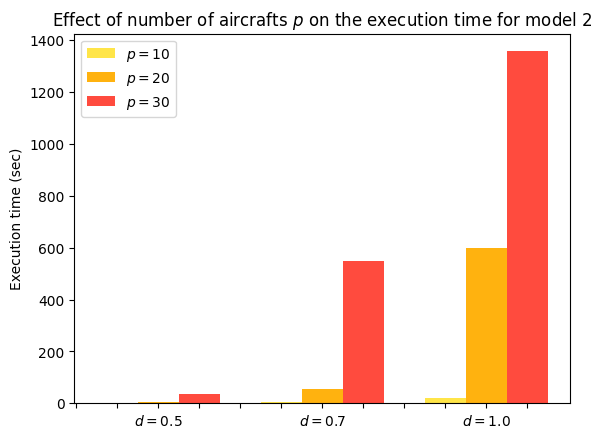

In [30]:
avg_times = []

for d in [0.5,0.7,1.0]:
    density5 = columns['density'] == d
    calc_times: np.ndarray = columns['flow_calc_time (s)'][density5]
    planes = columns['planes'][density5]

    for p in [10,20, 30]:
        by_planes = planes == p
        not_inf = np.isfinite(calc_times)
        avg_times.append(calc_times[np.logical_and(by_planes,not_inf)].mean())


fig, ax = plt.subplots()

ax.bar([1, 5, 9], avg_times[::3], 1, color='#FFE548')
ax.bar([2, 6, 10], avg_times[1::3], 1, color='#FFB20F')
ax.bar([3, 7, 11], avg_times[2::3], 1, color='#FF4B3E')
ax.set_xticks(range(12))
_ = ax.set_xticklabels(['', '','$d=0.5$', '','', '','$d=0.7$', '','','','$d=1.0$', ''])
ax.legend(['$p=10$', '$p=20$', '$p=30$'])
ax.set_ylabel('Execution time (sec)')
ax.set_title("Effect of number of aircrafts $p$ on the execution time for model 2")



Text(0.5, 1.0, 'Effect of horizon $h$ on the execution time for model 2')

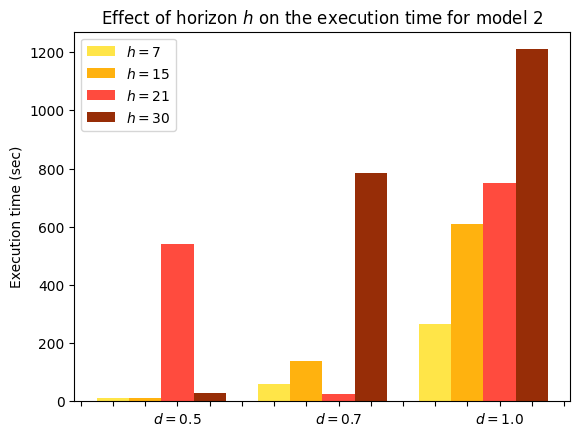

In [31]:
avg_times = []

for d in [0.5,0.7,1.0]:
    density5 = columns['density'] == d
    calc_times: np.ndarray = columns['flow_calc_time (s)'][density5]
    horizons = columns['horizon'][density5]

    for h in [7,15,21,30 ]:
        by_planes = horizons == h
        not_inf = np.isfinite(calc_times)
        not_nan = ~np.isnan(calc_times)
        avg_times.append(calc_times[np.logical_and(by_planes,not_inf, not_nan)].mean())

fig, ax = plt.subplots()

ax.bar([1, 6, 11], avg_times[::4], 1, color='#FFE548')
ax.bar([2, 7, 12], avg_times[1::4], 1, color='#FFB20F')
ax.bar([3, 8, 13], avg_times[2::4], 1, color='#FF4B3E')
ax.bar([4, 9, 14], avg_times[3::4], 1, color='#972D07')
ax.set_xticks(range(16))
_ = ax.set_xticklabels(['','', '','$d=0.5$', '','', '','','$d=0.7$','', '','', '','$d=1.0$', '',''])
ax.legend(['$h=7$', '$h=15$', '$h=21$', '$h=30$'])
ax.set_ylabel('Execution time (sec)')
ax.set_title("Effect of horizon $h$ on the execution time for model 2")

## Interval model

In [132]:
import itertools

In [137]:
D = [0.5, 0.7, 1]
P = [10, 20, 30, 40]
H = [7, 15, 21, 30]


def output_file_path(d, p, h, i):
    return f"./benchmarks/interval/problem_d={d}_p={p}_h={h}_i={i}/report_found_solution.txt"


columns_model1 = {
    "density": [],
    "horizon": [],
    "planes": [],
    "index": [],
    "calc_time": [],
}

for d, p, h, i in itertools.product(D, P, H, range(10)):
    file_path = output_file_path(d, p, h, i)

    try:

        with open(file_path, "r") as report:
            for line in report:
                if line.startswith("execution time"):
                    execution_time = float(line.split("=")[-1][:-2])
                    columns_model1['density'].append(d)
                    columns_model1['horizon'].append(h)
                    columns_model1['planes'].append(p)
                    columns_model1['index'].append(i)
                    columns_model1['calc_time'].append(execution_time)
    except FileNotFoundError:
        pass

for key in columns_model1:
    columns_model1[key] = np.array(columns_model1[key], dtype=float)

C:\Users\triba\AppData\Local\Temp\ipykernel_15236\2791100062.py:11: RuntimeWarning: Mean of empty slice.
  avg_times.append(calc_times[np.logical_and(by_planes,not_inf)].mean())
c:\Study\ST7 Optimisation transport\flight_problem\.env\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Effect of number of aircrafts $p$ on the execution time for model &')

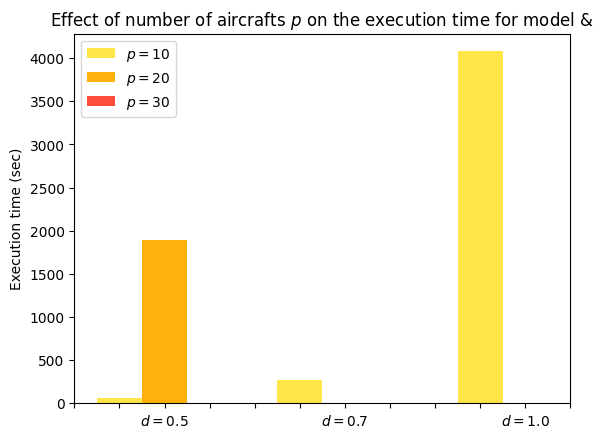

In [ ]:
avg_times = []

for d in [0.5,0.7,1.0]:
    density5 = columns_model1['density'] == d
    calc_times: np.ndarray = columns_model1['calc_time'][density5]
    planes = columns_model1['planes'][density5]

    for p in [10,20,30]:
        by_planes = planes == p
        not_inf = np.isfinite(calc_times)
        avg_times.append(calc_times[np.logical_and(by_planes,not_inf)].mean())


fig, ax = plt.subplots()

ax.bar([1, 5, 9], avg_times[::3], 1, color='#FFE548')
ax.bar([2, 6, 10], avg_times[1::3], 1, color='#FFB20F')
ax.bar([3, 7, 11], avg_times[2::3], 1, color='#FF4B3E')
ax.set_xticks(range(12))
_ = ax.set_xticklabels(['', '','$d=0.5$', '','', '','$d=0.7$', '','','','$d=1.0$', ''])
ax.legend(['$p=10$', '$p=20$', '$p=30$'])
ax.set_ylabel('Execution time (sec)')
ax.set_title("Effect of number of aircrafts $p$ on the execution time for model 1")

C:\Users\triba\AppData\Local\Temp\ipykernel_15236\2149563860.py:12: RuntimeWarning: Mean of empty slice.
  avg_times.append(calc_times[np.logical_and(by_planes,not_inf, not_nan)].mean())
c:\Study\ST7 Optimisation transport\flight_problem\.env\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Effect of horizon $h$ on the execution time for model 3')

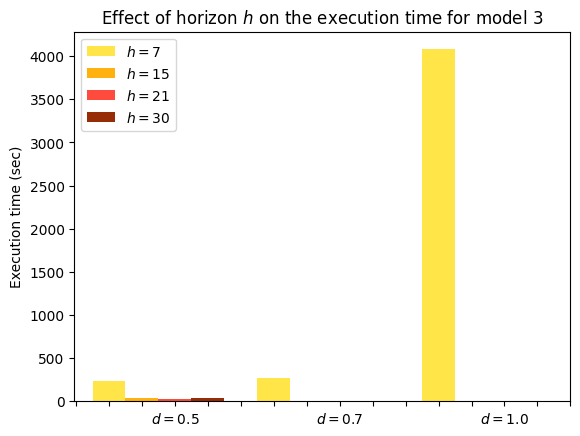

In [140]:
avg_times = []

for d in [0.5,0.7,1.0]:
    density5 = columns_model1['density'] == d
    calc_times: np.ndarray = columns_model1['calc_time'][density5]
    horizons = columns_model1['horizon'][density5]

    for h in [7,15,21,30 ]:
        by_planes = horizons == h
        not_inf = np.isfinite(calc_times)
        not_nan = ~np.isnan(calc_times)
        avg_times.append(calc_times[np.logical_and(by_planes,not_inf, not_nan)].mean())

fig, ax = plt.subplots()

ax.bar([1, 6, 11], avg_times[::4], 1, color='#FFE548')
ax.bar([2, 7, 12], avg_times[1::4], 1, color='#FFB20F')
ax.bar([3, 8, 13], avg_times[2::4], 1, color='#FF4B3E')
ax.bar([4, 9, 14], avg_times[3::4], 1, color='#972D07')
ax.set_xticks(range(16))
_ = ax.set_xticklabels(['','', '','$d=0.5$', '','', '','','$d=0.7$','', '','', '','$d=1.0$', '',''])
ax.legend(['$h=7$', '$h=15$', '$h=21$', '$h=30$'])
ax.set_ylabel('Execution time (sec)')
ax.set_title("Effect of horizon $h$ on the execution time for model 3")

In [143]:
print("{}\t|{}\t|{}\t|{}\t|{}\t".format('d','h', 'p', 'i', 'time'))
print("{}\t|{}\t|{}\t|{}\t|{}\t".format('------','------', '------', '------', '------'))
for instance in zip(*columns_model1.values()):
    print("{}\t|{}\t|{}\t|{}\t|{}\t".format(*instance))

d	|h	|p	|i	|time	
------	|------	|------	|------	|------	
0.5	|7.0	|10.0	|0.0	|113.479144	
0.5	|7.0	|10.0	|1.0	|31.777107	
0.5	|7.0	|10.0	|2.0	|183.919926	
0.5	|7.0	|10.0	|3.0	|45.302159	
0.5	|7.0	|10.0	|4.0	|93.481513	
0.5	|7.0	|10.0	|5.0	|28.247915	
0.5	|7.0	|10.0	|6.0	|62.444265	
0.5	|7.0	|10.0	|7.0	|67.526026	
0.5	|7.0	|10.0	|8.0	|87.407414	
0.5	|7.0	|10.0	|9.0	|45.210951	
0.5	|15.0	|10.0	|0.0	|42.188161	
0.5	|21.0	|10.0	|0.0	|24.39479	
0.5	|21.0	|10.0	|1.0	|22.747398	
0.5	|30.0	|10.0	|0.0	|30.042361	
0.5	|30.0	|10.0	|1.0	|38.169695	
0.5	|30.0	|10.0	|2.0	|86.488208	
0.5	|30.0	|10.0	|3.0	|17.364862	
0.5	|30.0	|10.0	|4.0	|56.342037	
0.5	|30.0	|10.0	|5.0	|21.675991	
0.5	|7.0	|20.0	|0.0	|1889.321265	
0.7	|7.0	|10.0	|0.0	|226.448189	
0.7	|7.0	|10.0	|1.0	|281.472313	
0.7	|7.0	|10.0	|2.0	|228.166629	
0.7	|7.0	|10.0	|3.0	|536.123875	
0.7	|7.0	|10.0	|4.0	|190.428537	
0.7	|7.0	|10.0	|5.0	|121.742669	
0.7	|7.0	|10.0	|6.0	|300.672587	
0.7	|7.0	|10.0	|7.0	|359.599942	
0.7	|7.0	|10.0	|8.0	|388.3

In [ ]:
# 0.5 10 7
np.mean([113.479144,
31.777107,
183.919926,
45.302159,
93.481513,
28.247915,
62.444265,
67.526026,
87.407414,
45.210951])

np.float64(75.87964200000002)

In [145]:
# 0.7 10 7.0
np.mean([
    226.448189,
281.472313,
228.166629,
536.123875,
190.428537,
121.742669,
300.672587,
359.599942,
388.375717,
104.295088,
])

np.float64(273.7325546)

In [ ]:
# 1.0	7.0 10.0
4079.43063